# Practical 1 — TensorFlow, Keras & PyTorch + MLP on Diabetes Dataset

**Objective:**
- Introduce TensorFlow, Keras, and PyTorch frameworks
- Configure GPU support on Google Colab
- Implement a Multilayer Perceptron (MLP) using the Pima Indians Diabetes Dataset

**Dataset:** Pima Indians Diabetes Dataset  
**Task:** Binary Classification (Diabetic or Not)

---
## SECTION 1 — GPU Configuration Check

In [ ]:
# ✅ STEP 1: Enable GPU in Colab first!
# Go to: Runtime → Change runtime type → Hardware accelerator → GPU (T4) → Save

# Check GPU with TensorFlow
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU Available (TF):", tf.config.list_physical_devices('GPU'))

# Check GPU with PyTorch
import torch

print("\nPyTorch version:", torch.__version__)
print("CUDA Available (PyTorch):", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    print("No GPU found — using CPU")
    device = torch.device("cpu")

print("\nUsing device:", device)

TensorFlow version: 2.19.0
GPU Available (TF): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

PyTorch version: 2.10.0+cu128
CUDA Available (PyTorch): True
GPU Name: Tesla T4

Using device: cuda


---
## SECTION 2 — Framework Introduction

In [ ]:
# Framework comparison summary
print("="*55)
print("  DEEP LEARNING FRAMEWORK COMPARISON")
print("="*55)

frameworks = {
    "TensorFlow": {
        "Creator"  : "Google",
        "Best For" : "Production & deployment",
        "Style"    : "Static & Dynamic graphs",
        "Version"  : tf.__version__
    },
    "Keras": {
        "Creator"  : "François Chollet (now part of TF)",
        "Best For" : "Beginners & fast prototyping",
        "Style"    : "High-level API on top of TensorFlow",
        "Version"  : tf.keras.__version__
    },
    "PyTorch": {
        "Creator"  : "Meta (Facebook)",
        "Best For" : "Research & custom models",
        "Style"    : "Dynamic computation graphs",
        "Version"  : torch.__version__
    }
}

for name, info in frameworks.items():
    print(f"\n📦 {name}")
    for key, val in info.items():
        print(f"   {key:10}: {val}")

  DEEP LEARNING FRAMEWORK COMPARISON

📦 TensorFlow
   Creator   : Google
   Best For  : Production & deployment
   Style     : Static & Dynamic graphs
   Version   : 2.19.0

📦 Keras
   Creator   : François Chollet (now part of TF)
   Best For  : Beginners & fast prototyping
   Style     : High-level API on top of TensorFlow
   Version   : 3.13.2

📦 PyTorch
   Creator   : Meta (Facebook)
   Best For  : Research & custom models
   Style     : Dynamic computation graphs
   Version   : 2.10.0+cu128


---
## SECTION 3 — Load & Explore Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load dataset directly from URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, header=None, names=columns)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Basic statistics
print("Dataset Info:")
print(df.info())
print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# Class distribution
print("Class Distribution:")
print(df['Outcome'].value_counts())
print(f"\nNon-Diabetic (0): {(df['Outcome']==0).sum()} samples")
print(f"Diabetic     (1): {(df['Outcome']==1).sum()} samples")

Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Non-Diabetic (0): 500 samples
Diabetic     (1): 268 samples


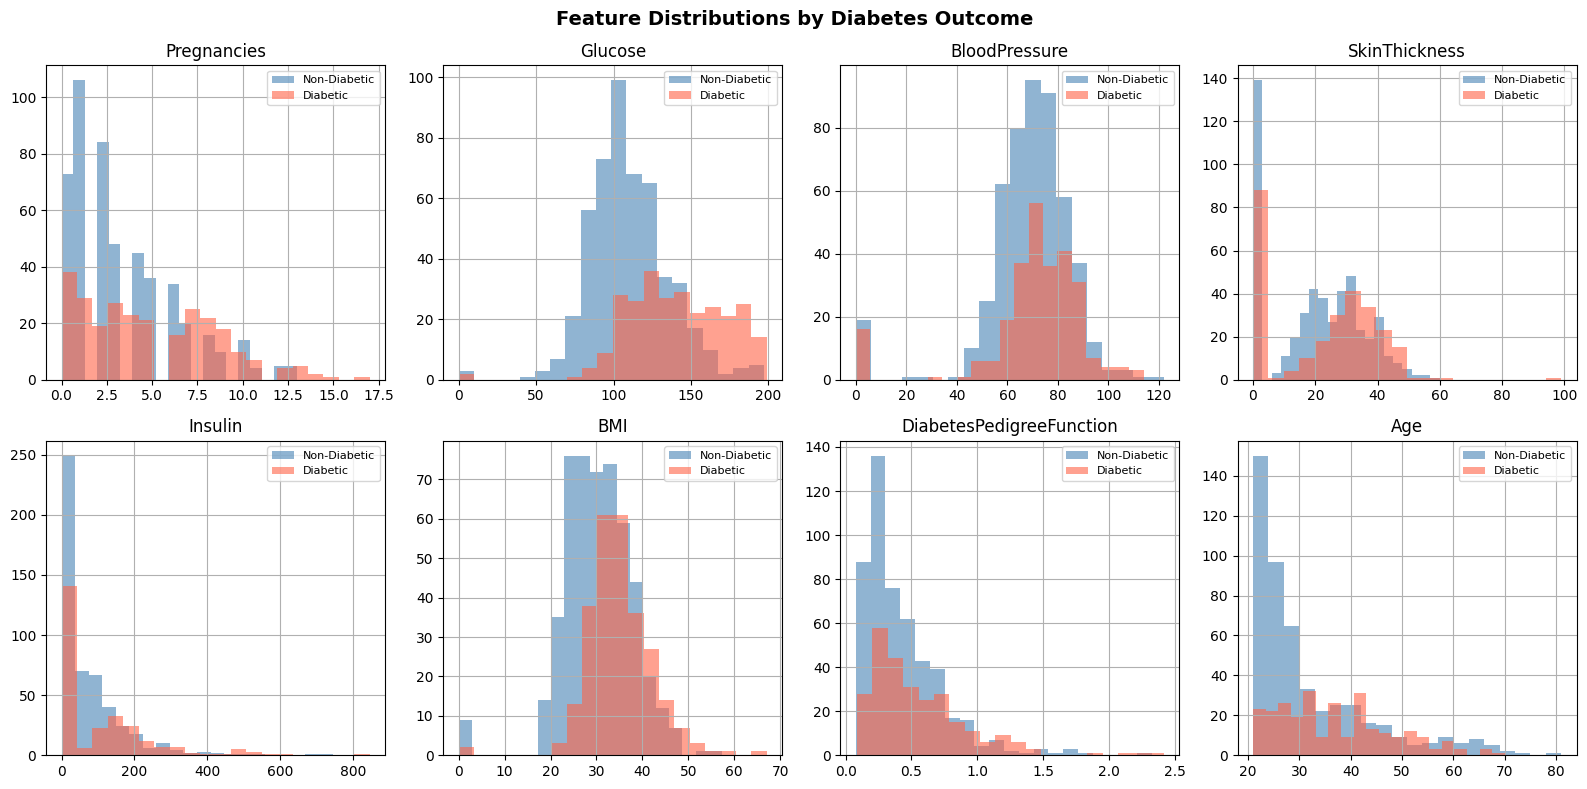

Figure saved as feature_distributions.png


In [ ]:
# Visualize the dataset
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Feature Distributions by Diabetes Outcome', fontsize=14, fontweight='bold')

features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for i, feature in enumerate(features):
    ax = axes[i//4][i%4]
    df[df['Outcome']==0][feature].hist(ax=ax, alpha=0.6, color='steelblue', label='Non-Diabetic', bins=20)
    df[df['Outcome']==1][feature].hist(ax=ax, alpha=0.6, color='tomato',    label='Diabetic',     bins=20)
    ax.set_title(feature)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as feature_distributions.png")

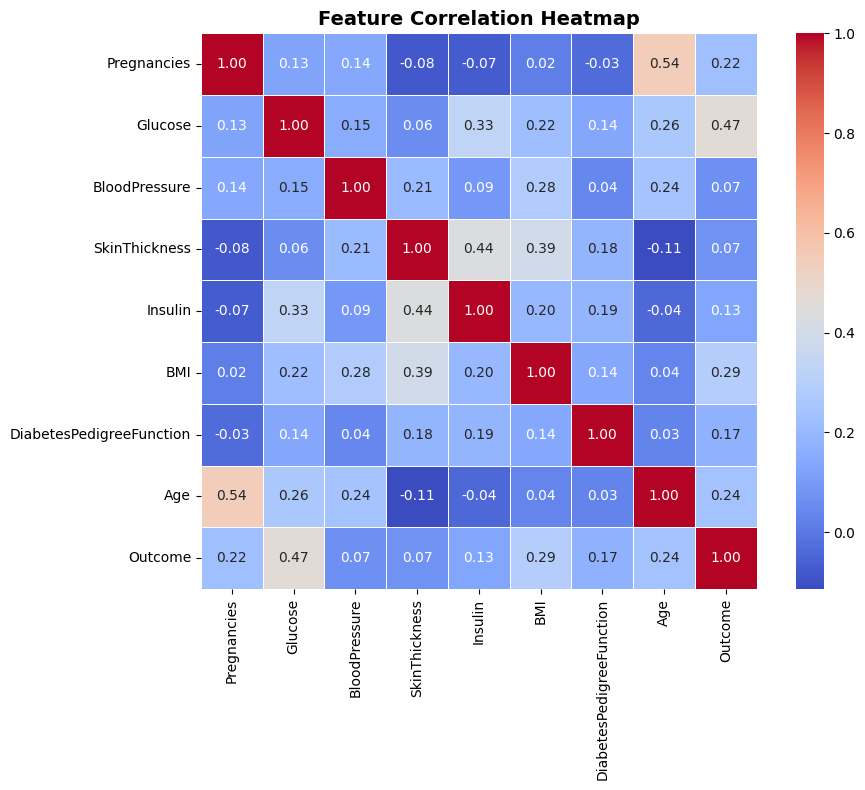

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION 4 — Data Preprocessing

In [ ]:
# Separate features and target
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

print("Features shape:", X.shape)
print("Labels shape  :", y.shape)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

# Feature scaling (StandardScaler: mean=0, std=1)
# IMPORTANT: fit only on training data, transform both train and test
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nAfter Scaling — Training set mean :", X_train.mean().round(4))
print("After Scaling — Training set std  :", X_train.std().round(4))

Features shape: (768, 8)
Labels shape  : (768,)

Training samples : 614
Testing  samples : 154

After Scaling — Training set mean : 0.0
After Scaling — Training set std  : 1.0


---
## SECTION 5 — MLP using KERAS (TensorFlow)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# ── Build the MLP model ──────────────────────────────────────
#
#  Input  →  [8 neurons]  (one per feature)
#     ↓
#  Dense  →  [16 neurons] + ReLU
#     ↓
#  Dense  →  [8 neurons]  + ReLU
#     ↓
#  Output →  [1 neuron]   + Sigmoid  (binary: 0 or 1)
#
# ────────────────────────────────────────────────────────────

keras_model = keras.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8,  activation='relu'),
    layers.Dense(1,  activation='sigmoid')
], name="Keras_MLP")

keras_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

keras_model.summary()

Model: "Keras_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early stopping — stop if val_loss doesn't improve for 10 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
print("Training Keras MLP...")
keras_history = keras_model.fit(
    X_train, y_train,
    epochs          = 150,
    batch_size      = 16,
    validation_split= 0.2,
    callbacks       = [early_stop],
    verbose         = 1
)

Training Keras MLP...
Epoch 1/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.5703 - loss: 0.6988 - val_accuracy: 0.6260 - val_loss: 0.6601
Epoch 2/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6314 - loss: 0.6257 - val_accuracy: 0.6423 - val_loss: 0.6007
Epoch 3/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6660 - loss: 0.5880 - val_accuracy: 0.6911 - val_loss: 0.5655
Epoch 4/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6823 - loss: 0.5640 - val_accuracy: 0.7154 - val_loss: 0.5462
Epoch 5/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7047 - loss: 0.5472 - val_accuracy: 0.7317 - val_loss: 0.5298
Epoch 6/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7088 - loss: 0.5320 - val_accuracy: 0.7480 - val_loss: 0.5198
Epoch 7/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7332 - loss: 0.5205 - val_accuracy: 0.7642 - val_loss: 0.5113
Epoch 8/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7576 - loss: 0.5108 - v

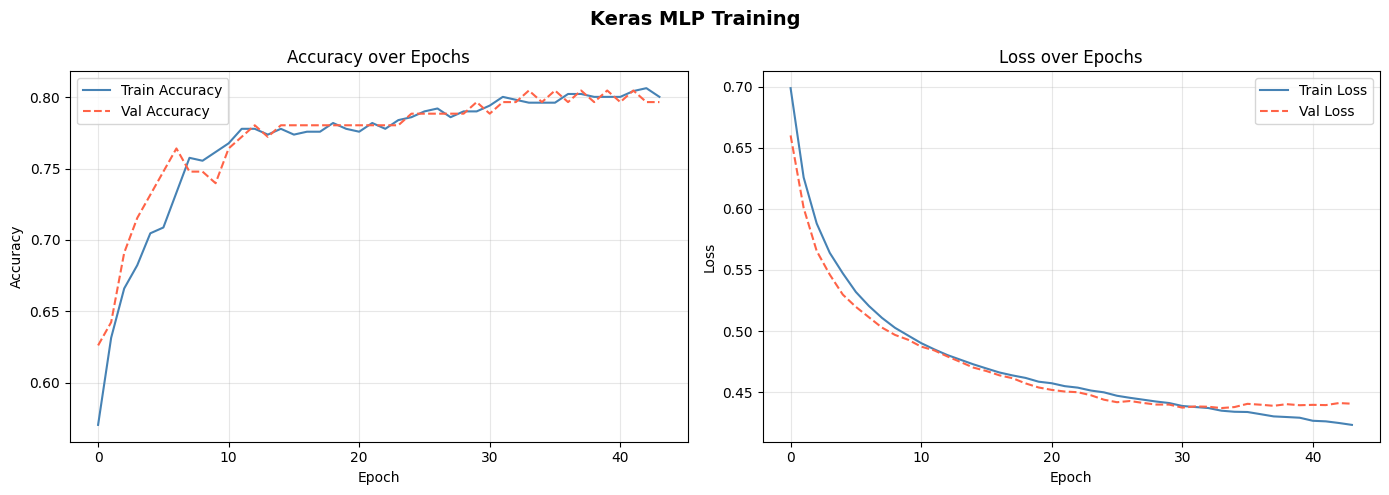

In [ ]:
# Plot training history
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Accuracy
    ax1.plot(history['accuracy'],     label='Train Accuracy', color='steelblue')
    ax1.plot(history['val_accuracy'], label='Val Accuracy',   color='tomato', linestyle='--')
    ax1.set_title('Accuracy over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Loss
    ax2.plot(history['loss'],     label='Train Loss', color='steelblue')
    ax2.plot(history['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
    ax2.set_title('Loss over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(keras_history.history, 'Keras MLP Training')

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step
  KERAS MODEL — TEST RESULTS
  Test Accuracy : 70.78%
  Test Loss     : 0.5176

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.79      0.78       100
    Diabetic       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



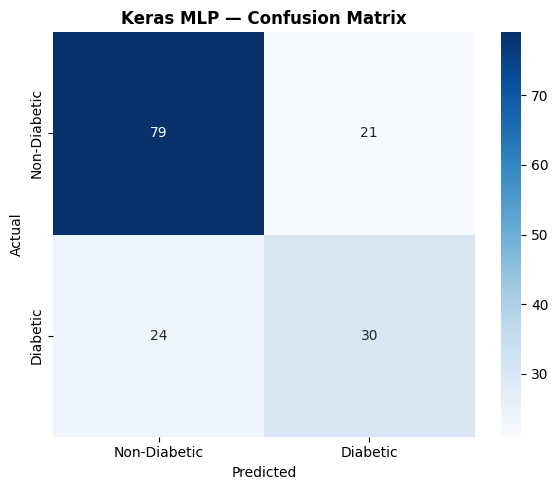

In [ ]:
# Evaluate Keras model
keras_loss, keras_acc = keras_model.evaluate(X_test, y_test, verbose=0)
y_pred_keras = (keras_model.predict(X_test) > 0.5).astype(int).flatten()

print("="*45)
print("  KERAS MODEL — TEST RESULTS")
print("="*45)
print(f"  Test Accuracy : {keras_acc*100:.2f}%")
print(f"  Test Loss     : {keras_loss:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_keras, target_names=['Non-Diabetic','Diabetic']))

# Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred_keras)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic','Diabetic'],
            yticklabels=['Non-Diabetic','Diabetic'])
plt.title('Keras MLP — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('keras_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION 6 — MLP using PYTORCH

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Convert numpy arrays to PyTorch tensors ──────────────────
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

# DataLoader for batch training
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)

print("Data converted to PyTorch tensors")
print("Training tensor shape :", X_train_t.shape)
print("Device in use         :", device)

Data converted to PyTorch tensors
Training tensor shape : torch.Size([614, 8])
Device in use         : cuda


In [ ]:
# ── Define the MLP model ─────────────────────────────────────
class DiabetesMLP(nn.Module):
    def __init__(self):
        super(DiabetesMLP, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(8,  16),   # Input  → Hidden 1
            nn.ReLU(),
            nn.Linear(16,  8),   # Hidden 1 → Hidden 2
            nn.ReLU(),
            nn.Linear(8,   1),   # Hidden 2 → Output
            nn.Sigmoid()         # Binary output
        )

    def forward(self, x):
        return self.network(x)


# Initialize model, loss function, optimizer
pytorch_model = DiabetesMLP().to(device)
criterion     = nn.BCELoss()                          # Binary Cross Entropy
optimizer     = optim.Adam(pytorch_model.parameters(), lr=0.001)

print("PyTorch MLP Architecture:")
print(pytorch_model)

# Count trainable parameters
total_params = sum(p.numel() for p in pytorch_model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params}")

PyTorch MLP Architecture:
DiabetesMLP(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Total trainable parameters: 289


In [ ]:
# ── Training loop ────────────────────────────────────────────
EPOCHS = 150

train_losses = []
train_accs   = []

print("Training PyTorch MLP...")

for epoch in range(EPOCHS):
    pytorch_model.train()
    epoch_loss = 0.0
    correct    = 0
    total      = 0

    for X_batch, y_batch in train_loader:
        # Forward pass
        outputs = pytorch_model(X_batch).squeeze()
        loss    = criterion(outputs, y_batch)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track metrics
        epoch_loss += loss.item()
        predicted   = (outputs > 0.5).float()
        correct    += (predicted == y_batch).sum().item()
        total      += y_batch.size(0)

    avg_loss = epoch_loss / len(train_loader)
    accuracy = correct / total
    train_losses.append(avg_loss)
    train_accs.append(accuracy)

    if (epoch + 1) % 30 == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}]  Loss: {avg_loss:.4f}  Accuracy: {accuracy*100:.2f}%")

print("\nTraining complete!")

Training PyTorch MLP...
Epoch [ 30/150]  Loss: 0.4369  Accuracy: 79.48%
Epoch [ 60/150]  Loss: 0.4156  Accuracy: 80.46%
Epoch [ 90/150]  Loss: 0.4025  Accuracy: 81.43%
Epoch [120/150]  Loss: 0.3879  Accuracy: 82.57%
Epoch [150/150]  Loss: 0.3648  Accuracy: 83.22%

Training complete!


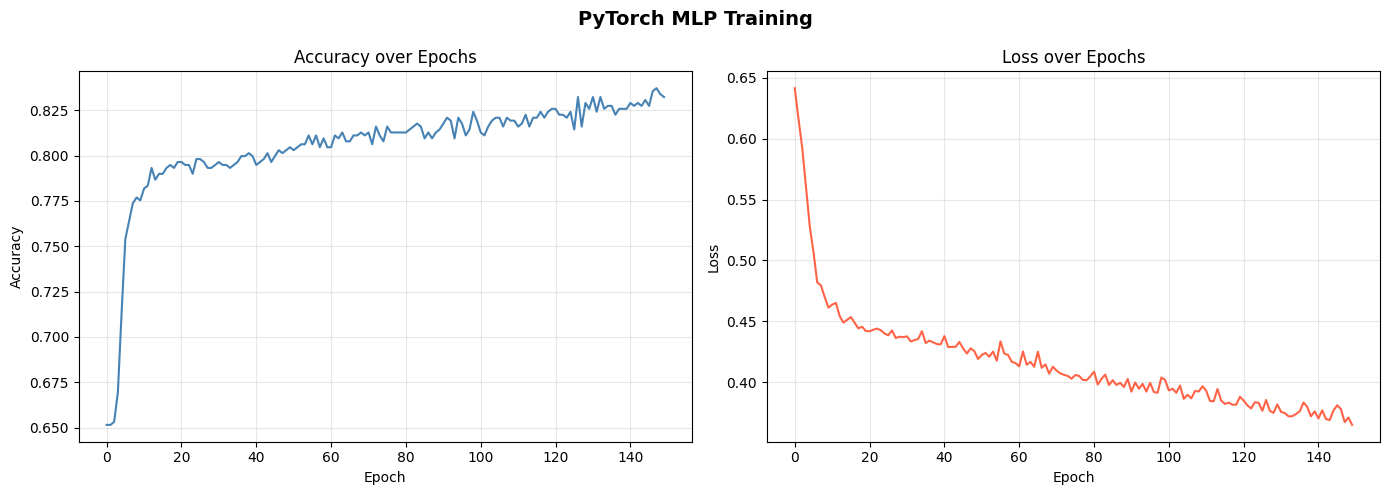

In [ ]:
# Plot PyTorch training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PyTorch MLP Training', fontsize=14, fontweight='bold')

ax1.plot(train_accs, color='steelblue')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.grid(alpha=0.3)

ax2.plot(train_losses, color='tomato')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('PyTorch_MLP_Training.png', dpi=150, bbox_inches='tight')
plt.show()

  PYTORCH MODEL — TEST RESULTS
  Test Accuracy : 71.43%

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.78      0.78      0.78       100
    Diabetic       0.59      0.59      0.59        54

    accuracy                           0.71       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.71      0.71      0.71       154



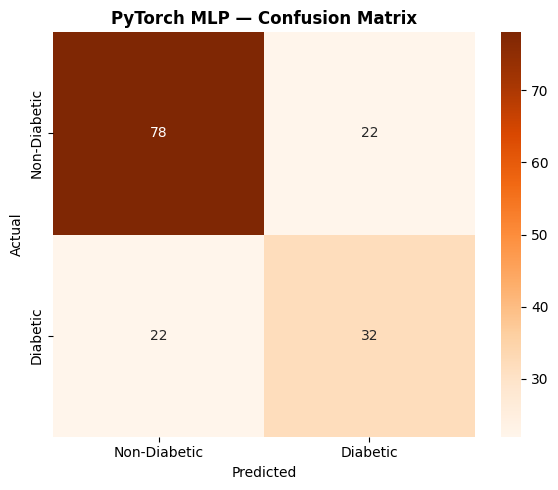

In [ ]:
# Evaluate PyTorch model
pytorch_model.eval()
with torch.no_grad():
    outputs      = pytorch_model(X_test_t).squeeze()
    y_pred_torch = (outputs > 0.5).cpu().numpy().astype(int)
    torch_acc    = accuracy_score(y_test, y_pred_torch)

print("="*45)
print("  PYTORCH MODEL — TEST RESULTS")
print("="*45)
print(f"  Test Accuracy : {torch_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_torch, target_names=['Non-Diabetic','Diabetic']))

# Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred_torch)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Diabetic','Diabetic'],
            yticklabels=['Non-Diabetic','Diabetic'])
plt.title('PyTorch MLP — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('pytorch_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION 7 — Final Comparison: Keras vs PyTorch

  FINAL RESULTS COMPARISON
  Model                    Accuracy       Framework
-------------------------------------------------------
  Keras MLP                 70.78%   TensorFlow/Keras
  PyTorch MLP               71.43%           PyTorch


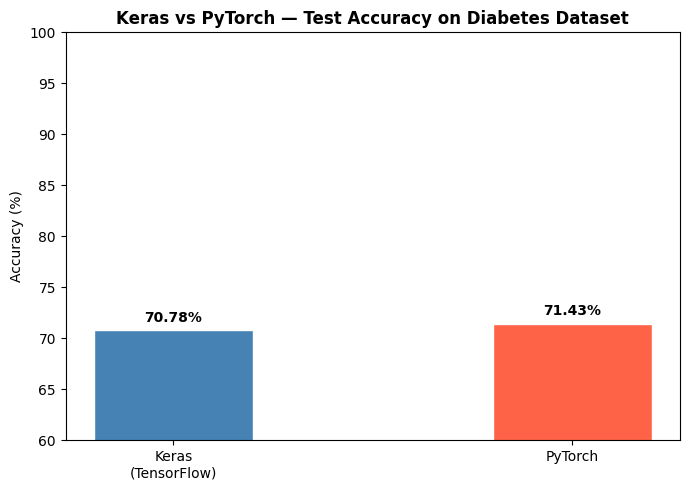

In [ ]:
# Side-by-side comparison
print("="*55)
print("  FINAL RESULTS COMPARISON")
print("="*55)
print(f"  {'Model':<20} {'Accuracy':>12} {'Framework':>15}")
print("-"*55)
print(f"  {'Keras MLP':<20} {keras_acc*100:>10.2f}%   {'TensorFlow/Keras':>15}")
print(f"  {'PyTorch MLP':<20} {torch_acc*100:>10.2f}%   {'PyTorch':>15}")
print("="*55)

# Bar chart comparison
models     = ['Keras\n(TensorFlow)', 'PyTorch']
accuracies = [keras_acc * 100, torch_acc * 100]
colors     = ['steelblue', 'tomato']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=colors, width=0.4, edgecolor='white')
plt.ylim(60, 100)
plt.title('Keras vs PyTorch — Test Accuracy on Diabetes Dataset', fontweight='bold')
plt.ylabel('Accuracy (%)')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('framework_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION 8 — Key Learnings

| Topic | Observation |
|-------|-------------|
| **GPU Setup** | Colab GPU enabled via Runtime → Change runtime type → GPU |
| **Keras** | Simpler code, fewer lines — great for fast prototyping |
| **PyTorch** | More control over training loop — better for custom research |
| **Accuracy** | Both frameworks achieve similar results (~75-80%) |
| **Activation** | ReLU in hidden layers, Sigmoid in output (binary classification) |
| **Loss Function** | Binary Cross Entropy — standard for binary classification |
| **Optimizer** | Adam — adaptive learning rate, faster convergence than SGD |
| **Scaling** | StandardScaler is essential — improves convergence significantly |

---
*Practical 1 complete ✅ — Part of [Deep Learning Portfolio](https://github.com/GauriShinde911/deep-learning-portfolio)*